# Visualizations

In [2]:
import pandas as pd
import psycopg2

# Connect to RDS 

conn = psycopg2.connect(
    host="worldbank-db.c8hyu8gkak7d.us-east-1.rds.amazonaws.com",
    port=5432,
    dbname="postgres",
    user="postgres",
    password="Georgetown2026!",
    sslmode="require"
)

df = pd.read_sql("SELECT * FROM worldbank_panel", conn)
df.head()

C:\Users\Samantha\AppData\Local\Temp\ipykernel_38052\3288937361.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM worldbank_panel", conn)


,country_code,country_name,year,internet_users_pct,gdp_per_capita,life_expectancy,secondary_enrollment_pct,ingested_at
0,ABW,Aruba,2000,15.442823,20681.023027,72.939,91.580200,2026-04-16T16:11:51.246302+00:00
1,ABW,Aruba,2001,17.100000,20740.132583,73.044,97.556534,2026-04-16T16:11:51.246302+00:00
2,ABW,Aruba,2002,18.800000,21307.248251,73.135,100.163063,2026-04-16T16:11:51.246302+00:00
3,ABW,Aruba,2003,20.800000,21949.485996,73.236,101.929070,2026-04-16T16:11:51.246302+00:00
4,ABW,Aruba,2004,23.000000,23700.631990,73.223,100.940941,2026-04-16T16:11:51.246302+00:00


## World Map (Internet Access)

In [15]:
import pandas as pd
import plotly.express as px
import plotly.io as pio


pio.renderers.default = "notebook_connected"


# filter for most recent year
df_latest = df[df['year'] == df['year'].max()].copy()

# -------------------------------------------------
# 2. Clean numeric variable (CRITICAL FIX)
# -------------------------------------------------
df_latest['internet_users_pct'] = pd.to_numeric(
    df_latest['internet_users_pct'],
    errors='coerce'
)


df_latest['country_code'] = df_latest['country_code'].astype(str).str.upper()


df_latest = df_latest.dropna(subset=['country_code', 'internet_users_pct'])

# remove any remaining junk codes (non ISO-3)
df_latest = df_latest[df_latest['country_code'].str.len() == 3]

# ensure values are valid
df_latest = df_latest[
    (df_latest['internet_users_pct'] >= 0) &
    (df_latest['internet_users_pct'] <= 100)
]


print("Rows:", df_latest.shape[0])
print("Unique countries:", df_latest['country_code'].nunique())
print("Internet % range:", df_latest['internet_users_pct'].min(), df_latest['internet_users_pct'].max())


fig = px.choropleth(
    df_latest,
    locations="country_code",
    locationmode="ISO-3",
    color="internet_users_pct",
    hover_name="country_name",
    color_continuous_scale="Viridis",
    range_color=(0, 100),
    projection="natural earth",
    title="Global Internet Penetration (Most Recent Year)"
)


fig.update_layout(
    margin=dict(l=0, r=0, t=50, b=0),
    coloraxis_colorbar=dict(title="Internet Access (%)")
)

fig.update_geos(
    showcoastlines=True,
    coastlinecolor="LightGray",
    showland=True,
    landcolor="whitesmoke",
    showocean=True,
    oceancolor="lightblue"
)


fig.show(renderer="browser")

Rows: 210
Unique countries: 210
Internet % range: 7.172299862 100.0


In [16]:
# Export html

fig.write_html("internet_map.html")

## Internet vs GDP Scatter

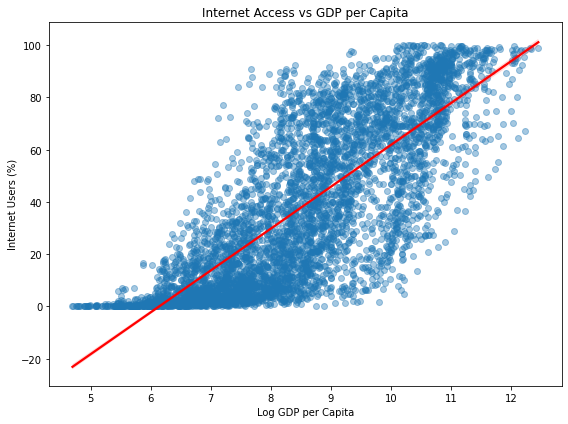

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Ensure log GDP exists
df['log_gdp_pc'] = np.log(df['gdp_per_capita'])

plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x='log_gdp_pc',
    y='internet_users_pct',
    scatter_kws={'alpha':0.4},
    line_kws={'color':'red'}
)

plt.title('Internet Access vs GDP per Capita')
plt.xlabel('Log GDP per Capita')
plt.ylabel('Internet Users (%)')

# save figure
plt.tight_layout()
plt.savefig("internet_vs_gdp.png", dpi=300)

plt.show()

## Internet vs Enrollment (with nonlinear curve)

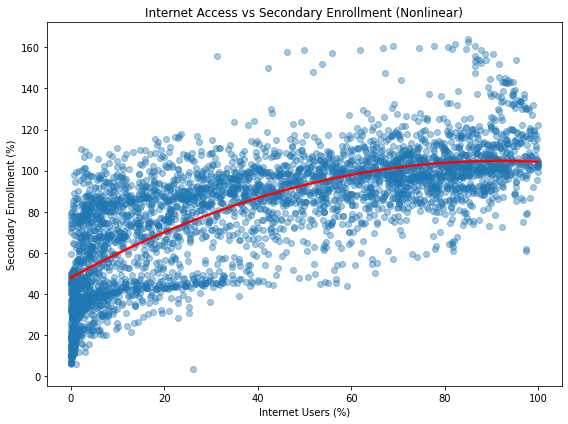

In [27]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x='internet_users_pct',
    y='secondary_enrollment_pct',
    order=2,  # quadratic fit
    scatter_kws={'alpha':0.4},
    line_kws={'color':'red'}
)

plt.title('Internet Access vs Secondary Enrollment (Nonlinear)')
plt.xlabel('Internet Users (%)')
plt.ylabel('Secondary Enrollment (%)')

# save figure
plt.tight_layout()
plt.savefig("internet_vs_enrollment.png", dpi=300)

plt.show()

## Global trends by income group

C:\Users\Samantha\AppData\Local\Temp\ipykernel_38052\109234751.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = df.groupby(['year', 'income_group'])['internet_users_pct'].mean().reset_index()


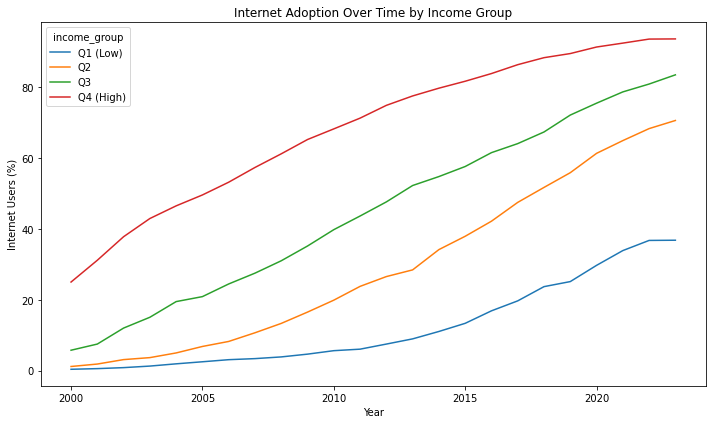

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Create income groups (within each year to avoid bias)
df['income_group'] = df.groupby('year')['gdp_per_capita'].transform(
    lambda x: pd.qcut(x, 4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])
)

trend = df.groupby(['year', 'income_group'])['internet_users_pct'].mean().reset_index()

plt.figure(figsize=(10,6))

sns.lineplot(
    data=trend,
    x='year',
    y='internet_users_pct',
    hue='income_group'
)

plt.title('Internet Adoption Over Time by Income Group')
plt.ylabel('Internet Users (%)')
plt.xlabel('Year')

# save figure
plt.tight_layout()
plt.savefig("trends_by_income_group.png", dpi=300)

plt.show()

## Digital Divide - inequality in digital access over time

C:\Users\Samantha\AppData\Local\Temp\ipykernel_38052\1457738390.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gap = df.groupby('year').apply(


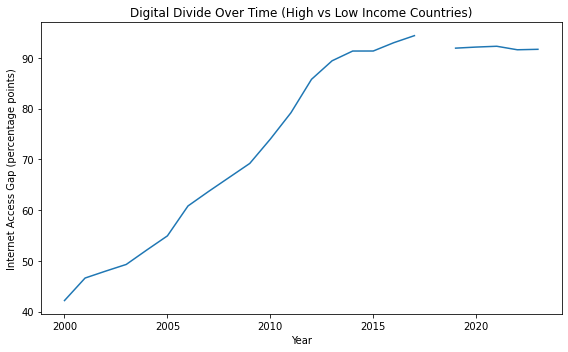

In [29]:
gap = df.groupby('year').apply(
    lambda x: x.loc[x['gdp_per_capita'].idxmax(), 'internet_users_pct'] -
              x.loc[x['gdp_per_capita'].idxmin(), 'internet_users_pct']
).reset_index(name='internet_gap')

plt.figure(figsize=(8,5))

plt.plot(gap['year'], gap['internet_gap'])

plt.title('Digital Divide Over Time (High vs Low Income Countries)')
plt.xlabel('Year')
plt.ylabel('Internet Access Gap (percentage points)')

# save figure
plt.tight_layout()
plt.savefig("digital_inequality_over_time.png", dpi=300)

plt.show()

## Distribution of internet access over time

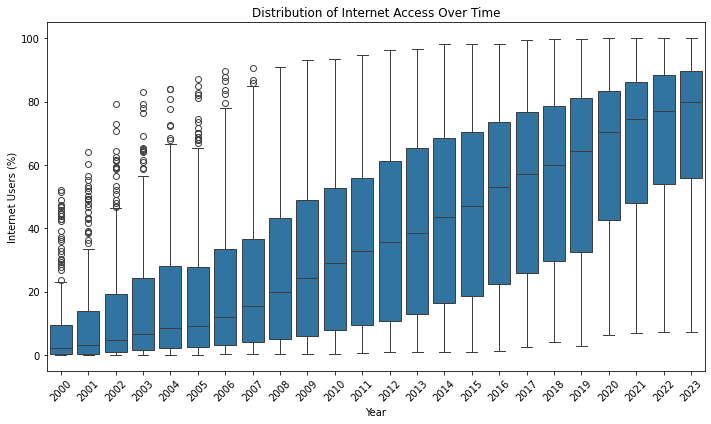

In [30]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='year',
    y='internet_users_pct'
)

plt.xticks(rotation=45)
plt.title('Distribution of Internet Access Over Time')
plt.xlabel('Year')
plt.ylabel('Internet Users (%)')

# save figure
plt.tight_layout()
plt.savefig("internet_distribution_over_time.png", dpi=300)

plt.show()

In [31]:
conn.close()
print("Connection closed.")

Connection closed.
